In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Source

The `Symptom2Disease.csv` dataset, obtained from Kaggle, consists of 1,200 data points and includes two columns: “label” and “text”.
-	The “label” column contains the disease names, serving as the target variable.
-	The “text” column contains natural language descriptions of symptoms associated with each disease.

The dataset covers 24 distinct diseases, with 50 symptom descriptions per disease (including 47 duplicate records).

This dataset will serve as the source of the sentence-level training set and will be converted into TF-IDF or BOW format.
The dataset used for clustering, which consists of detailed descriptions of diseases (`Disease_Description.csv`) from an authoritative medical book, will serve as the source of the topic-level training set and will be converted into LDA format.
These two different levels of data formats will be assigned different weights and combined as the input to the model.

---
**DTI5125/GNG5125 Winter2025 Group 24**
*   Teewalee Asawaniwed 300407716
*   Rang Zhang 300435329
*   Jie Wang 300434583

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from scipy.stats import loguniform, uniform
from scipy.sparse import hstack
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import MaxAbsScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Load the sentence-level dataset
symptom_file = '/content/drive/MyDrive/GNG5125_Group24_Project/Symptom2Disease.csv'
df_symptom = pd.read_csv(symptom_file)

# Load the topic-level dataset
description_file = '/content/drive/MyDrive/GNG5125_Group24_Project/Disease_Description.csv'
df_description = pd.read_csv(description_file)

# Load the dataset that maps diseases to departments
department_mapping_file = '/content/drive/MyDrive/GNG5125_Group24_Project/Disease2Department.csv'
df_department_mapping = pd.read_csv(department_mapping_file)

# Remove unnecessary column if it exists
df_symptom.drop(columns=["Unnamed: 0"], inplace=True)

# Print the original shape of the symptom dataset
print("Original shape of the dataset from Symptom2Disease.csv:", df_symptom.shape)

# Remove duplicate rows and reset the index
df_symptom = df_symptom.drop_duplicates().reset_index(drop=True)

# Convert disease labels to title case (capitalize the first letter of each word)
df_symptom['label'] = df_symptom['label'].str.title()

# Combine multiple description fields in df_description
# Define a function to concatenate selected columns into one string
def combine_row_info(row):
    parts = []
    for col in ['definition', 'description', 'causes_and_symptoms']:
        if col in row and pd.notnull(row[col]):
            parts.append(str(row[col]))
    return ' '.join(parts)

# Create a new column 'combined_info' to store the concatenated description content
df_description['combined_info'] = df_description.apply(combine_row_info, axis=1)

# Group by disease_name, concatenate combined_info for diseases with multiple rows (remove duplicates)
df_description_agg = df_description.groupby('disease_name')['combined_info'] \
    .apply(lambda x: ' '.join(x.dropna().unique())).reset_index()

# Create a description dictionary:
# keys are lowercased and stripped disease names, values are the merged description info
description_dict = pd.Series(
    df_description_agg['combined_info'].values,
    index=df_description_agg['disease_name'].str.strip().str.lower()
).to_dict()

# Map the merged descriptions to df_symptom based on label matching
df_symptom['description'] = df_symptom['label'].str.strip().str.lower().map(description_dict)

# Check for diseases that failed to match any description
unmatched_diseases = df_symptom[df_symptom['description'].isnull()]['label'].unique()
if len(unmatched_diseases) > 0:
    print(f"Warning: {len(unmatched_diseases)} diseases were not found in the description dictionary, e.g.: {unmatched_diseases[:3]}")

# Print the shape of the dataset after deduplication and adding descriptions
print("Shape after removing duplicates and adding descriptions:", df_symptom.shape)
unique_diseases = df_symptom['label'].unique()

# Print total number of unique diseases and their names
print("Number of unique diseases:", len(unique_diseases))

# Retrieve 'text' and 'description' columns for further preprocessing
symptoms = df_symptom['text']
descriptions = df_symptom['description']

Original shape of the dataset from Symptom2Disease.csv: (1200, 2)
Shape after removing duplicates and adding descriptions: (1153, 3)
Number of unique diseases: 24


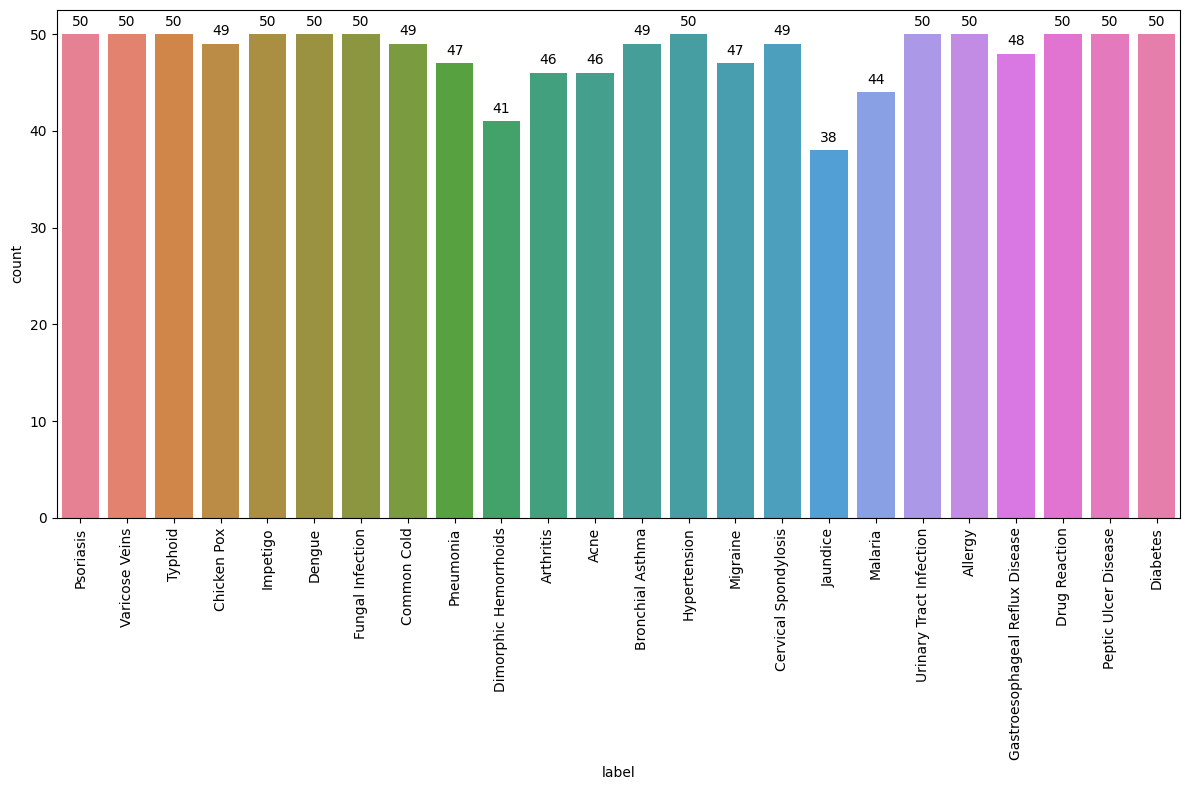

In [58]:
max_len = 150
# Generate a discrete 'husl' palette based on the number of unique labels in the dataset.
colors = sns.color_palette('husl', len(df_symptom['label'].unique()))

# Create a figure with a size of 12 x 8 inches.
plt.figure(figsize=(12, 8))

# Create a count plot for the 'label' column.
# The 'hue' is set to 'label' to meet future requirements.
fig = sns.countplot(x='label', data=df_symptom, hue='label', palette=colors, dodge=False)

# Remove the automatically generated legend (since hue duplicates the x variable).
if fig.get_legend():
    fig.legend_.remove()

# Rotate the x-axis labels by 90 degrees for better readability.
plt.xticks(rotation=90)
plt.tight_layout()

# Annotate each bar with its count.
for p in fig.patches:
    fig.annotate(format(p.get_height(), '.0f'),
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 9),
                 textcoords='offset points')

# Display the plot.
plt.show()
plt.close('all')
del fig

# Data Preprocessing for Classfication

- **TF-IDF / BOW Format:**  
  Removing stop words reduces the feature space and noise, allowing the model to focus on discriminative keywords and improve classification performance.

- **LDA Format:**  
Stop words appear frequently in text yet offer little meaningful information. Removing them allows LDA to extract more coherent topics, and when these topics are combined with TF-IDF features, classifier performance can be improved.

In [59]:
# Global definition of custom stop words tuple
stop_words_custom = (
    'feel', 'feeling', 'felt', 'work', 'meeting', 'Along with', 'In addition to',
    'Doctor', 'doctor', 'Definition', 'definition', 'Causes', 'causes',
    'Symptoms', 'symptoms', 'Diagnosis', 'diagnosis'
)

def preprocess_text(text):
    # Convert text to lowercase and tokenize
    words = word_tokenize(text.lower())

    # Build a custom stop words set: start with NLTK's standard stopwords and add custom words.
    cachedStopWords = set(stopwords.words("english"))
    cachedStopWords.update(stop_words_custom)

    # Remove non-alphabetic tokens and any token that appears in the custom stop words set.
    words = [word for word in words if word.isalpha() and word not in cachedStopWords]

    return ' '.join(words)

# Copy the original dataset to keep the 'label' column
df_preprocessed = df_symptom.copy()

# Apply the preprocess_text function to the 'text' and 'description' column
df_preprocessed['text'] = symptoms.apply(preprocess_text)
df_preprocessed['description'] = descriptions.apply(preprocess_text)

# Display the preprocessed DataFrame to check the results
display(df_preprocessed)

,label,text,description
0,Psoriasis,experiencing skin rash arms legs torso past we...,psychosis symptom feature mental illness typic...
1,Psoriasis,skin peeling especially knees elbows scalp pee...,psychosis symptom feature mental illness typic...
2,Psoriasis,experiencing joint pain fingers wrists knees p...,psychosis symptom feature mental illness typic...
3,Psoriasis,silver like dusting skin especially lower back...,psychosis symptom feature mental illness typic...
4,Psoriasis,nails small dents pits often inflammatory tend...,psychosis symptom feature mental illness typic...
...,...,...,...
1148,Diabetes,shaking trembling lost sense taste smell exhau...,diabetes insipidus di disorder patient produce...
1149,Diabetes,particularly crevices skin skin rashes irritat...,diabetes insipidus di disorder patient produce...
1150,Diabetes,regularly experience intense urges want urinat...,diabetes insipidus di disorder patient produce...
1151,Diabetes,trouble breathing especially outside start hot...,diabetes insipidus di disorder patient produce...


In [60]:
# Convert text data using TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()
x = tfidf_vectorizer.fit_transform(df_preprocessed["text"])

# Check sparsity of the TF-IDF matrix
non_zero_elements = x.count_nonzero()
total_elements = x.shape[0] * x.shape[1]
sparsity = 1 - (non_zero_elements / total_elements)
print(f"Non-zero elements: {non_zero_elements}")
print(f"Sparsity (percentage of zeros): {sparsity:.2%}")

Non-zero elements: 16483
Sparsity (percentage of zeros): 99.00%


# Feature Engineering for Classfication

## SGD Performance Evaluation: TF-IDF vs. BOW

In [65]:
def plot_confusion_matrix(y_true, y_pred, label_encoder, normalize=False, custom_title=None):
    """
    Plots a confusion matrix using seaborn's heatmap.

    Parameters:
        y_true (array-like): The true labels.
        y_pred (array-like): The predicted labels.
        label_encoder (LabelEncoder): The label encoder that was used to encode the labels,
                                      so that the original class names can be retrieved.
        normalize (bool): If True, the confusion matrix will be normalized by row. Default is False.
        custom_title (str): A custom title for the plot. If None, no title is set.

    Returns:
        None: The function displays the plot.
    """

    cm = confusion_matrix(y_true, y_pred)
    labels = label_encoder.classes_
    if normalize:
        cm = np.round(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis], 2)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    # Set the title if a custom title is provided
    if custom_title:
        plt.title(custom_title)
    plt.tight_layout()
    plt.show()

In [63]:
# Define SGD parameter distribution
param_dist_sgd = {
    'alpha': loguniform(1e-5, 1e-2),           # Log-uniform distribution for alpha
    'loss': ['log_loss', 'modified_huber'],    # List of loss functions to try
    'penalty': ['l2', 'l1']                    # Regularization options
}

# Define feature extraction methods: BOW and TF-IDF
feature_extractors = {
    "BOW": CountVectorizer(),
    "TF-IDF": TfidfVectorizer(),
}

# Use preprocessed text data
text_data = df_preprocessed["text"]

# Train and evaluate SGD model for each feature extraction method
print("Parameter Optimization for SGD (Random Search):")

# Store confusion matrix data for all methods
confusion_results = []

for method, extractor in feature_extractors.items():
    print(f"\n--- Feature Representation Type: {method} ---")

    # Transform text data
    x = extractor.fit_transform(text_data)
    y = df_preprocessed["label"]

    # Split data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
    )

    # Encode string labels into numeric labels using LabelEncoder
    le = LabelEncoder()
    # Generate mapping from training labels and transform them into numbers
    y_train_encoded = le.fit_transform(y_train)
    # Transform testing labels using the same mapping
    y_test_encoded = le.transform(y_test)

    # Initialize RandomizedSearchCV for hyperparameter tuning
    random_search = RandomizedSearchCV(
        estimator=SGDClassifier(random_state=42),
        param_distributions=param_dist_sgd,
        n_iter=100,         # Try 100 different parameter settings
        cv=10,              # Use 10-fold cross-validation
        scoring='accuracy',
        n_jobs=-1,          # Use all available CPU cores
        verbose=0,
        random_state=42,
        return_train_score=True
    )

    # Train the model with randomized search
    random_search.fit(x_train, y_train_encoded)

    # Get cross-validation scores for the best parameter set
    best_idx = random_search.best_index_
    cv_scores = [random_search.cv_results_[f'split{i}_test_score'][best_idx] for i in range(10)]
    mean_cv_score = np.mean(cv_scores)
    std_cv_score = np.std(cv_scores)

    # Evaluate the best model on the test set
    best_sgd = random_search.best_estimator_
    y_pred = best_sgd.predict(x_test)

    # Calculate accuracy and generate classification report
    accuracy_val = accuracy_score(y_test_encoded, y_pred)
    report = classification_report(y_test_encoded, y_pred, target_names=le.classes_, zero_division=0)
    class_distribution = dict(zip(*np.unique(y_pred, return_counts=True)))

    # Output results
    best_params_formatted = {k: float(v) if isinstance(v, np.float64) else v
                         for k, v in random_search.best_params_.items()}
    print(f"Best Parameters: {best_params_formatted}")
    print(f"Cross-validation Accuracy: {mean_cv_score:.4f} (±{std_cv_score:.4f})")
    print(f"Test Accuracy: {accuracy_val:.4f}")
    print("\nClassification Report:")
    print(report)

    # Save evaluation data for later confusion matrix visualization
    confusion_data = {
        "method": method,
        "y_true": y_test_encoded,
        "y_pred": y_pred,
        "label_encoder": le
    }
    confusion_results.append(confusion_data)

Parameter Optimization for SGD (Random Search):

--- Feature Representation Type: BOW ---
Best Parameters: {'alpha': 0.007715105777813051, 'loss': 'modified_huber', 'penalty': 'l2'}
Cross-validation Accuracy: 0.9740 (±0.0120)
Test Accuracy: 0.9524

Classification Report:
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         9
                        Allergy       1.00      0.90      0.95        10
                      Arthritis       1.00      1.00      1.00         9
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical Spondylosis       1.00      1.00      1.00        10
                    Chicken Pox       0.90      0.90      0.90        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.90      0.90      0.90        10
                       Diabetes       1.00      0.90      0.95        

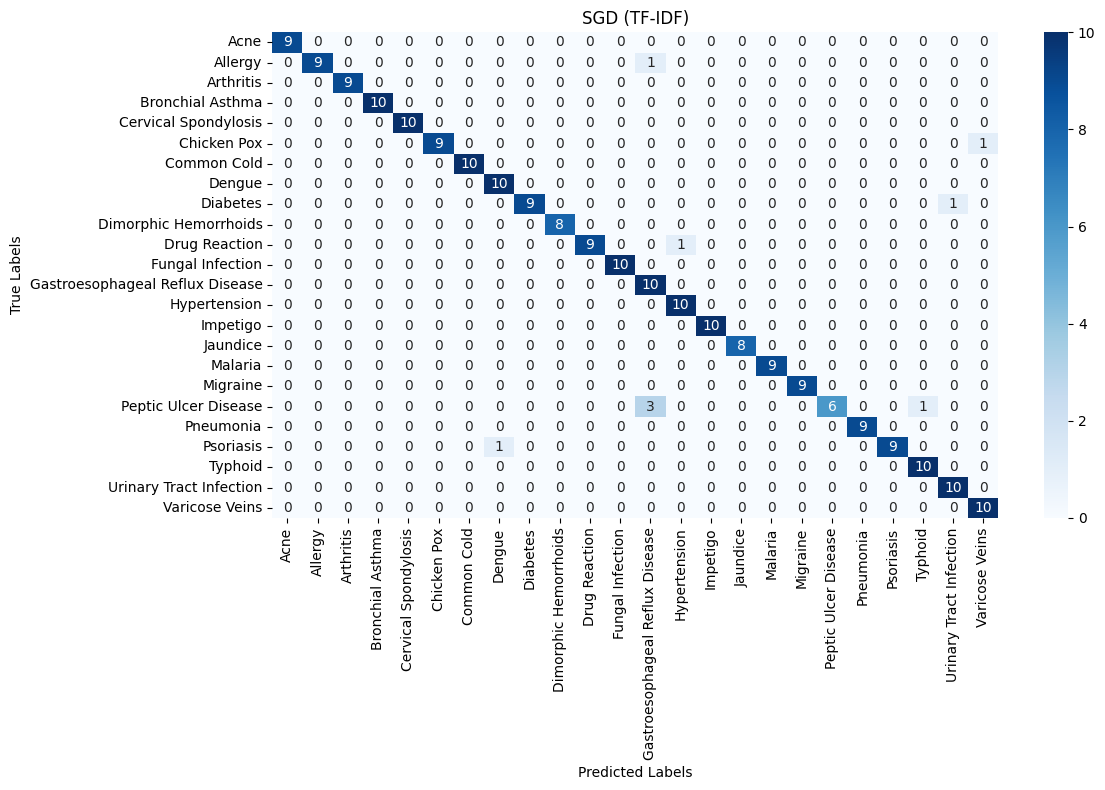

In [66]:
# Visualize the confusion matrix only for the "TF-IDF" method
for item in confusion_results:
    if item["method"] == "TF-IDF":
        custom_title = f"SGD ({item['method']})"
        plot_confusion_matrix(
            y_true=item["y_true"],
            y_pred=item["y_pred"],
            label_encoder=item["label_encoder"],
            normalize=False,
            custom_title=custom_title
        )

## Logistic Regression Performance Evaluation: TF-IDF vs. BOW

In [ ]:
# Define parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],   # Inverse regularization strength
    'penalty': ['l1', 'l2'],         # Regularization options
    'solver': ['liblinear']          # Solver supporting both l1 and l2 penalties
}

# Define feature extraction methods: BOW and TF-IDF
feature_extractors = {
    "BOW": CountVectorizer(),
    "TF-IDF": TfidfVectorizer(),
}

# Use preprocessed text data
text_data = df_preprocessed["text"]

# Train and evaluate Logistic Regression model for each feature extraction method
print("Parameter Optimization for Logistic Regression (Grid Search):")

# Store confusion matrix data for all methods
confusion_results = []

for method, extractor in feature_extractors.items():
    print(f"\n--- Feature Representation Type: {method} ---")

    # Transform text data
    x = extractor.fit_transform(text_data)
    y = df_preprocessed["label"]

    # Split data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
    )

    # Encode string labels into numeric labels using LabelEncoder
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)

    # Initialize GridSearchCV for hyperparameter tuning of Logistic Regression
    grid_search = GridSearchCV(
        estimator=LogisticRegression(random_state=42, max_iter=1000),
        param_grid=param_grid_lr,
        cv=10,              # Use 10-fold cross-validation
        scoring='accuracy',
        n_jobs=-1,          # Use all available CPU cores
        verbose=0
    )

    # Train the model with grid search
    grid_search.fit(x_train, y_train_encoded)

    # Evaluate the best model on the test set
    best_lr = grid_search.best_estimator_
    y_pred = best_lr.predict(x_test)

    # Calculate accuracy and generate classification report
    accuracy_val = accuracy_score(y_test_encoded, y_pred)
    report = classification_report(y_test_encoded, y_pred, target_names=le.classes_, zero_division=0)

    # Format best parameters to convert any np.float64 to native floats
    best_params_formatted = {k: float(v) if isinstance(v, np.float64) else v
                             for k, v in grid_search.best_params_.items()}

    print(f"Best Parameters: {best_params_formatted}")
    print(f"Cross-validation Accuracy: {mean_cv_score:.4f} (±{std_cv_score:.4f})")
    print(f"Test Accuracy: {accuracy_val:.4f}")
    print("\nClassification Report:")
    print(report)

    # Save evaluation data for later confusion matrix visualization
    confusion_data = {
        "method": method,
        "y_true": y_test_encoded,
        "y_pred": y_pred,
        "label_encoder": le
    }
    confusion_results.append(confusion_data)

Parameter Optimization for Logistic Regression (Grid Search):

--- Feature Representation Type: BOW ---
Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Cross-validation Accuracy: 0.9772 (±0.0090)
Test Accuracy: 0.9481

Classification Report:
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         9
                        Allergy       0.90      0.90      0.90        10
                      Arthritis       1.00      1.00      1.00         9
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical Spondylosis       1.00      1.00      1.00        10
                    Chicken Pox       0.90      0.90      0.90        10
                    Common Cold       1.00      0.90      0.95        10
                         Dengue       0.82      0.90      0.86        10
                       Diabetes       1.00      0.90      0.95        10
       

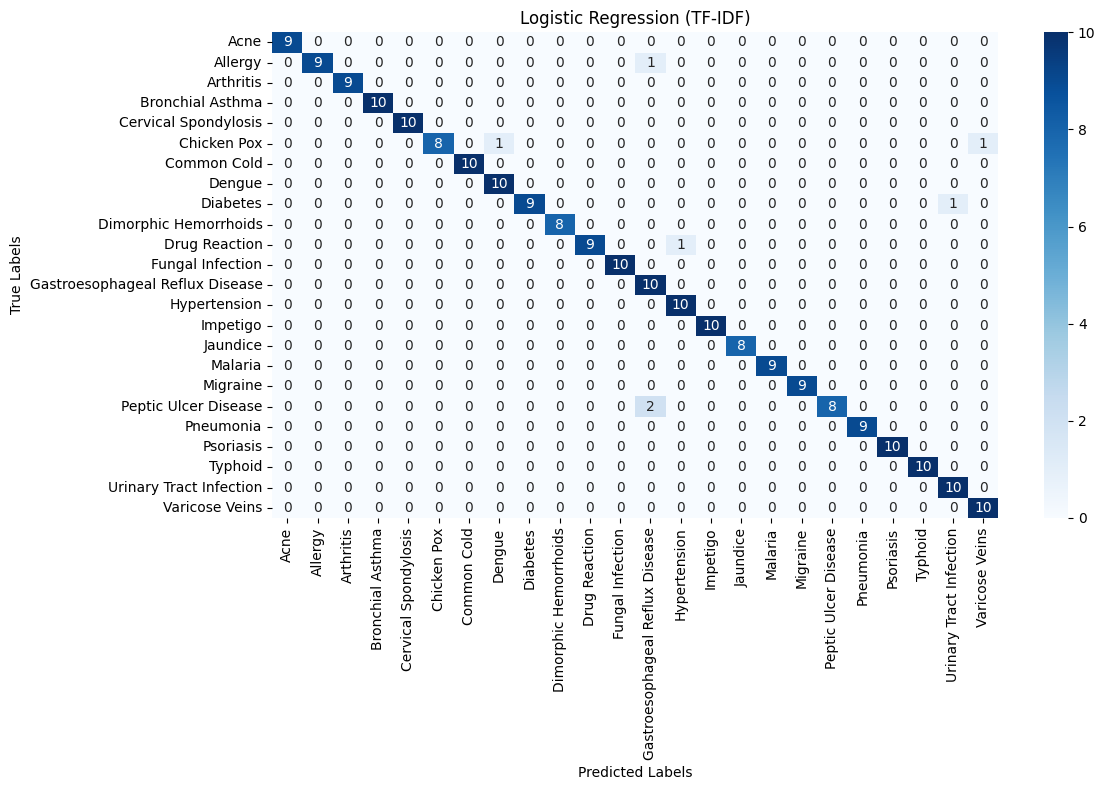

In [ ]:
# Visualize the confusion matrix only for the "TF-IDF" method
for item in confusion_results:
    if item["method"] == "TF-IDF":
        custom_title = f"Logistic Regression ({item['method']})"
        plot_confusion_matrix(
            y_true=item["y_true"],
            y_pred=item["y_pred"],
            label_encoder=item["label_encoder"],
            normalize=False,
            custom_title=custom_title
        )

## LinearSVC Performance Evaluation: TF-IDF vs. BOW

In [ ]:
# Define parameter grid for LinearSVC
param_grid_lsvc = {
    'C': [0.01, 0.1, 1, 10, 100]   # Inverse regularization strength
}

# Define feature extraction methods: BOW and TF-IDF
feature_extractors = {
    "BOW": CountVectorizer(),
    "TF-IDF": TfidfVectorizer(),
}

# Use preprocessed text data
text_data = df_preprocessed["text"]

# Train and evaluate LinearSVC model for each feature extraction method
print("Parameter Optimization for LinearSVC (Grid Search):")

# Store confusion matrix data for all methods
confusion_results = []

for method, extractor in feature_extractors.items():
    print(f"\n--- Feature Representation Type: {method} ---")

    # Transform text data
    x = extractor.fit_transform(text_data)
    y = df_preprocessed["label"]

    # Split data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
    )

    # Encode string labels into numeric labels using LabelEncoder
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)

    # Initialize GridSearchCV for hyperparameter tuning of LinearSVC
    grid_search = GridSearchCV(
        estimator=LinearSVC(random_state=42, max_iter=10000),
        param_grid=param_grid_lsvc,
        cv=10,              # Use 10-fold cross-validation
        scoring='accuracy',
        n_jobs=-1,          # Use all available CPU cores
        verbose=0
    )

    # Train the model with grid search
    grid_search.fit(x_train, y_train_encoded)

    # Compute cross-validation scores for the best parameter set
    best_idx = grid_search.best_index_
    cv_scores = [grid_search.cv_results_[f'split{i}_test_score'][best_idx] for i in range(10)]
    mean_cv_score = np.mean(cv_scores)
    std_cv_score = np.std(cv_scores)

    # Evaluate the best model on the test set
    best_lsvc = grid_search.best_estimator_
    y_pred = best_lsvc.predict(x_test)

    # Calculate accuracy and generate classification report
    accuracy_val = accuracy_score(y_test_encoded, y_pred)
    report = classification_report(y_test_encoded, y_pred, target_names=le.classes_, zero_division=0)

    # Format best parameters to convert any np.float64 to native floats
    best_params_formatted = {k: float(v) if isinstance(v, np.float64) else v
                             for k, v in grid_search.best_params_.items()}

    print(f"Best Parameters: {best_params_formatted}")
    print(f"Cross-validation Accuracy: {mean_cv_score:.4f} (±{std_cv_score:.4f})")
    print(f"Test Accuracy: {accuracy_val:.4f}")
    print("\nClassification Report:")
    print(report)

    # Save evaluation data for later confusion matrix visualization
    confusion_data = {
        "method": method,
        "y_true": y_test_encoded,
        "y_pred": y_pred,
        "label_encoder": le
    }
    confusion_results.append(confusion_data)

Parameter Optimization for LinearSVC (Grid Search):

--- Feature Representation Type: BOW ---
Best Parameters: {'C': 10}
Cross-validation Accuracy: 0.9751 (±0.0168)
Test Accuracy: 0.9654

Classification Report:
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         9
                        Allergy       0.90      0.90      0.90        10
                      Arthritis       1.00      1.00      1.00         9
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical Spondylosis       1.00      1.00      1.00        10
                    Chicken Pox       0.90      0.90      0.90        10
                    Common Cold       1.00      0.90      0.95        10
                         Dengue       0.83      1.00      0.91        10
                       Diabetes       1.00      1.00      1.00        10
          Dimorphic Hemorrhoids       1.00      1.00      

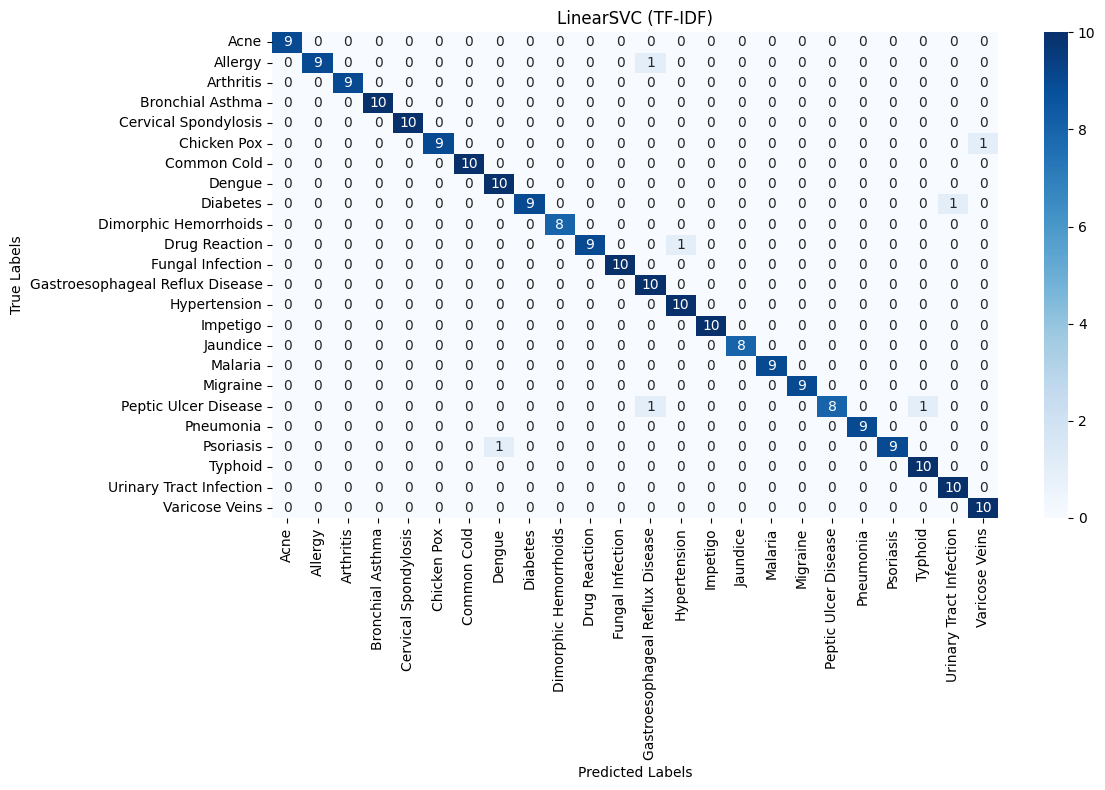

In [ ]:
# Visualize the confusion matrix only for the "TF-IDF" method
for item in confusion_results:
    if item["method"] == "TF-IDF":
        custom_title = f"LinearSVC ({item['method']})"
        plot_confusion_matrix(
            y_true=item["y_true"],
            y_pred=item["y_pred"],
            label_encoder=item["label_encoder"],
            normalize=False,
            custom_title=custom_title
        )

## Random Forest Performance Evaluation: TF-IDF vs. BOW

In [ ]:
# Define parameter grid for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [50, 100, 150, 200],      # Number of trees in the forest
    'max_depth': [None, 10, 20],        # Maximum depth of the trees
}

# Define feature extraction methods: BOW and TF-IDF
feature_extractors = {
    "BOW": CountVectorizer(),
    "TF-IDF": TfidfVectorizer(),
}

# Use preprocessed text data
text_data = df_preprocessed["text"]

# Store confusion matrix data for all methods
confusion_results = []

# Train and evaluate LinearSVC model for each feature extraction method
print("Parameter Optimization for Random Forest (Grid Search):")

for method, extractor in feature_extractors.items():
    print(f"\n--- Feature Representation Type: {method} ---")

    # Transform text data
    x = extractor.fit_transform(text_data)
    y = df_preprocessed["label"]

    # Split data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
    )

    # Encode string labels into numeric labels using LabelEncoder
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)

    # Initialize GridSearchCV for hyperparameter tuning of RandomForestClassifier
    grid_search = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid_rf,
        cv=10,              # Use 10-fold cross-validation
        scoring='accuracy',
        n_jobs=-1,          # Use all available CPU cores
        verbose=0
    )

    # Train the model with grid search
    grid_search.fit(x_train, y_train_encoded)

    # Compute cross-validation scores for the best parameter set
    best_idx = grid_search.best_index_
    cv_scores = [grid_search.cv_results_[f'split{i}_test_score'][best_idx] for i in range(10)]
    mean_cv_score = np.mean(cv_scores)
    std_cv_score = np.std(cv_scores)

    # Evaluate the best model on the test set
    best_rf = grid_search.best_estimator_
    y_pred = best_rf.predict(x_test)

    # Calculate accuracy and generate classification report
    accuracy_val = accuracy_score(y_test_encoded, y_pred)
    report = classification_report(y_test_encoded, y_pred, target_names=le.classes_, zero_division=0)

    # Format best parameters to convert any np.float64 to native floats
    best_params_formatted = {k: float(v) if isinstance(v, np.float64) else v
                             for k, v in grid_search.best_params_.items()}

    print(f"Best Parameters: {best_params_formatted}")
    print(f"Cross-validation Accuracy: {mean_cv_score:.4f} (±{std_cv_score:.4f})")
    print(f"Test Accuracy: {accuracy_val:.4f}")
    print("\nClassification Report:")
    print(report)

    # Save evaluation data for later confusion matrix visualization
    confusion_data = {
        "method": method,
        "y_true": y_test_encoded,
        "y_pred": y_pred,
        "label_encoder": le
    }
    confusion_results.append(confusion_data)

Parameter Optimization for Random Forest (Grid Search):

--- Feature Representation Type: BOW ---
Best Parameters: {'max_depth': None, 'n_estimators': 150}
Cross-validation Accuracy: 0.9588 (±0.0261)
Test Accuracy: 0.9481

Classification Report:
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         9
                        Allergy       0.91      1.00      0.95        10
                      Arthritis       1.00      1.00      1.00         9
               Bronchial Asthma       0.91      1.00      0.95        10
           Cervical Spondylosis       0.91      1.00      0.95        10
                    Chicken Pox       0.88      0.70      0.78        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       1.00      0.70      0.82        10
                       Diabetes       1.00      1.00      1.00        10
          Dimorphic Hem

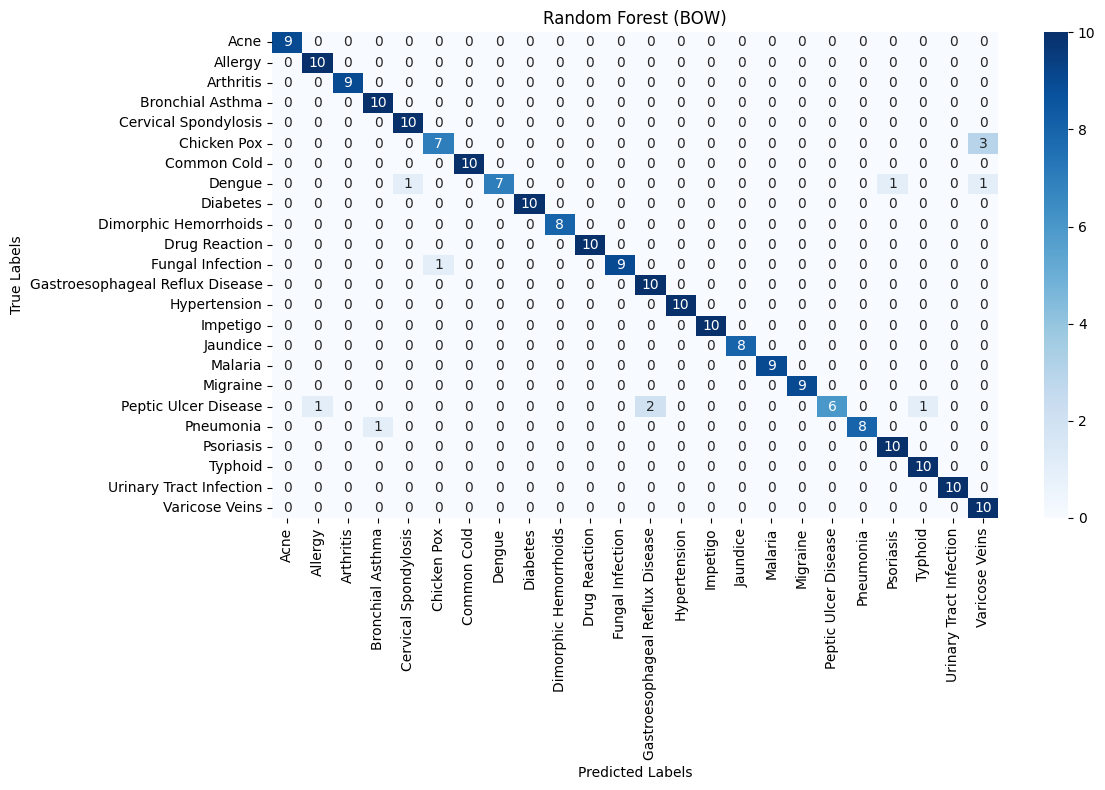

In [ ]:
# Visualize the confusion matrix only for the "BOW" method
for item in confusion_results:
    if item["method"] == "BOW":
        custom_title = f"Random Forest ({item['method']})"
        plot_confusion_matrix(
            y_true=item["y_true"],
            y_pred=item["y_pred"],
            label_encoder=item["label_encoder"],
            normalize=False,
            custom_title=custom_title
        )

## Feature Representation: TF-IDF plus LDA (using BOW)

1. Enhanced Feature Representation
- LDA: Extracts document themes from an authoritative medical book, providing a broad semantic context.
- TF-IDF: Highlights distinctive terms from patients' symptom descriptions while reducing noise from common words.

2. Complementary Strengths
- LDA: Captures topic-level semantics, offering a comprehensive global perspective.
- TF-IDF: Retains the importance of critical words, focusing on local details.

3. Combined Approach

  Considering that the sample size in the `Symptom2Disease.csv` file may only cover common cases, and may not be comprehensive enough when patients consult through a Medical Chatbot. Therefore, assigning a higher weight to TF-IDF and a lower weight to LDA can enhance the model's generalization ability.


In [80]:
# Adjust this factor for LDA weight as needed
scaling_factor = 0.2

# Separate text data and description data
text_data = df_preprocessed["text"]
desc_data = df_preprocessed["description"]

# Extract BOW features for LDA from the description data
lda_vectorizer = CountVectorizer()  # BOW for LDA
x_bow = lda_vectorizer.fit_transform(desc_data)

# Apply LDA to get document-topic distributions
lda = LatentDirichletAllocation(
    n_components=10,       # Number of topics
    max_iter=100,          # 100 iterations
    learning_method='online',
    random_state=42
)
x_lda = lda.fit_transform(x_bow)

# Fit scaler on rich training LDA data
# Standardize LDA features
lda_scaler = MaxAbsScaler()
x_lda_maxabs= lda_scaler.fit_transform(x_lda)
# Scale down LDA features to lower their weight
x_lda_scaled = x_lda_maxabs * scaling_factor

# Extract TF-IDF features from the text data
tfidf_vectorizer = TfidfVectorizer()
x_tfidf = tfidf_vectorizer.fit_transform(text_data)

# Combine the scaled LDA features with the TF-IDF features
x_combined = hstack([x_lda_scaled, x_tfidf])

# Extract target labels (disease categories) from the preprocessed dataset
y = df_preprocessed["label"]

# Check the shape of the combined features
print("Shape of combined features:", x_combined.shape)

if x_combined.shape[0] != len(df_preprocessed):
    raise ValueError("Number of rows in combined features does not match the original dataset.")

# Save the combined features and labels to a CSV file
df_combined_features = pd.DataFrame(x_combined.toarray())

# Create column names for LDA and TF-IDF features
lda_columns = [f"LDA_Feature_{i+1}" for i in range(x_lda_scaled.shape[1])]
tfidf_columns = [f"TFIDF_Feature_{i+1}" for i in range(x_tfidf.shape[1])]
df_combined_features.columns = lda_columns + tfidf_columns

# Append the labels to the DataFrame
df_combined_features["label"] = df_preprocessed["label"].reset_index(drop=True)

# Define the output file path (for example, in Colab's /content/ directory)
output_file = "/content/df_combined_features.csv"
df_combined_features.to_csv(output_file, index=False)

print("Combined features saved to:", output_file)

Shape of combined features: (1153, 1442)
Combined features saved to: /content/df_combined_features.csv


# Encapsulated Model

Among all the best models obtained through parameter optimization, the **SGD model using TF-IDF** features demonstrated the highest overall performance, as reflected by the combined metrics of cross-validation accuracy (mean and standard deviation) and test accuracy.

Therefore, when incorporating feature augmentation with **TF-IDF plus LDA (using BOW)**, we have decided to retrain the SGD model and perform further hyperparameter tuning to obtain the optimal model.


In [ ]:
# Convert disease-to-department mapping DataFrame into a dictionary
department_map = dict(zip(df_department_mapping["Disease"], df_department_mapping["Department"]))
print(department_map )

{'Psoriasis': 'Dermatology', 'Fungal Infection': 'Dermatology', 'Common Cold': 'General Medicine', 'Acne': 'Dermatology', 'Hypertension': 'Cardiology', 'Varicose Veins': 'Vascular Surgery', 'Typhoid': 'Infectious Diseases', 'Chicken Pox': 'Pediatrics', 'Impetigo': 'Dermatology', 'Dengue': 'Infectious Diseases', 'Pneumonia': 'Pulmonology', 'Dimorphic Hemorrhoids': 'Colorectal Surgery', 'Arthritis': 'Rheumatology', 'Bronchial Asthma': 'Pulmonology', 'Migraine': 'Neurology', 'Cervical Spondylosis': 'Neurology', 'Jaundice': 'Hepatology', 'Malaria': 'Infectious Diseases', 'Urinary Tract Infection': 'Urology', 'Allergy': 'Allergy and Immunology', 'Gastroesophageal Reflux Disease': 'Gastroenterology', 'Drug Reaction': 'Dermatology', 'Peptic Ulcer Disease': 'Gastroenterology', 'Diabetes': 'Endocrinology'}


In [68]:
# Define parameter distribution
param_dist_sgd = {
    'alpha': loguniform(1e-5, 1e-2),
    'loss': ['log_loss', 'modified_huber'],
    'penalty': ['l2', 'l1']
}

# Initialize base SGD model
base_model = SGDClassifier(random_state=42)

# Set up randomized search with 10-fold CV
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist_sgd,
    n_iter=50,                  # Try 50 different combinations
    cv=10,                      # 10-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=0,
    random_state=42,
    return_train_score=True
)

# Encode string labels into numeric labels using LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Run parameter search
random_search.fit(x_combined, y_encoded)

# Output best parameters and performance
best_params = random_search.best_params_
best_score = random_search.best_score_
best_model = random_search.best_estimator_

# Format best parameters to convert any np.float64 to native floats
best_params_formatted = {k: float(v) if isinstance(v, np.float64) else v
                         for k, v in random_search.best_params_.items()}
print("SGD Parameter Tuning Completed")
print(f"Best Parameters: {best_params_formatted}")
print(f"Cross-Validation Accuracy: {best_score:.4f}")

SGD Parameter Tuning Completed
Best Parameters: {'alpha': 1.6736010167825783e-05, 'loss': 'log_loss', 'penalty': 'l2'}
Cross-Validation Accuracy: 0.9948


In [70]:
%%writefile model.py

import joblib
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from scipy.sparse import hstack

# Define custom stop words (additional words to remove)
stop_words_custom = {
    "feel", "feeling", "felt", "work", "meeting", "Along with", "In addition to",
    "Doctor", "doctor", "Definition", "definition", "Causes", "causes",
    "Symptoms", "symptoms", "Diagnosis", "diagnosis"
}

# Define a mapping from disease names to recommended departments
department_map = {
    'Psoriasis': 'Dermatology',
    'Fungal Infection': 'Dermatology',
    'Common Cold': 'General Medicine',
    'Acne': 'Dermatology',
    'Hypertension': 'Cardiology',
    'Varicose Veins': 'Vascular Surgery',
    'Typhoid': 'Infectious Diseases',
    'Chicken Pox': 'Pediatrics',
    'Impetigo': 'Dermatology',
    'Dengue': 'Infectious Diseases',
    'Pneumonia': 'Pulmonology',
    'Dimorphic Hemorrhoids': 'Colorectal Surgery',
    'Arthritis': 'Rheumatology',
    'Bronchial Asthma': 'Pulmonology',
    'Migraine': 'Neurology',
    'Cervical Spondylosis': 'Neurology',
    'Jaundice': 'Hepatology',
    'Malaria': 'Infectious Diseases',
    'Urinary Tract Infection': 'Urology',
    'Allergy': 'Allergy and Immunology',
    'Gastroesophageal Reflux Disease': 'Gastroenterology',
    'Drug Reaction': 'Dermatology',
    'Peptic Ulcer Disease': 'Gastroenterology',
    'Diabetes': 'Endocrinology'
}

class DiseasePredictor:
    """
    A class that encapsulates all the components needed to process input text,
    extract features, and predict the disease along with a recommended department.
    """

    def __init__(self, tfidf_vectorizer, lda_vectorizer, lda_model, lda_scaler,
                 classifier, label_encoder, scaling_factor=0.2):
        # Initialize model components from training
        self.tfidf_vectorizer = tfidf_vectorizer
        self.lda_vectorizer = lda_vectorizer
        self.lda_model = lda_model
        self.lda_scaler = lda_scaler
        self.classifier = classifier
        self.label_encoder = label_encoder
        self.scaling_factor = scaling_factor

        # Load default English stopwords and update with custom stop words
        self.stop_words = set(stopwords.words("english"))
        self.stop_words.update(stop_words_custom)

        # Set the department mapping for diseases
        self.department_map = department_map

    def preprocess_text(self, text):
        """
        Preprocess the input text by lowercasing, tokenizing, and filtering out stopwords
        and non-alphabetic tokens.
        """
        words = word_tokenize(text.lower())
        filtered = [word for word in words if word.isalpha() and word not in self.stop_words]
        return ' '.join(filtered)

    def predict(self, symptom_text, full_text):
        """
        Process input symptom and full text, extract features using TF-IDF and LDA,
        combine them, and use the classifier to predict the disease. Also, map the
        predicted disease to a recommended department.
        """
        # Clean the input texts
        cleaned_symptom = self.preprocess_text(symptom_text)
        cleaned_full = self.preprocess_text(full_text)

        # Transform the cleaned text into features
        x_tfidf = self.tfidf_vectorizer.transform([cleaned_symptom])
        x_bow = self.lda_vectorizer.transform([cleaned_full])
        x_lda = self.lda_model.transform(x_bow)
        x_lda_scaled = self.lda_scaler.transform(x_lda) * self.scaling_factor

        # Combine features from LDA and TF-IDF
        x_combined = hstack([x_lda_scaled, x_tfidf])

        # Predict the disease using the classifier
        y_pred = self.classifier.predict(x_combined)
        y_pred_label = self.label_encoder.inverse_transform(y_pred)[0]

        # Get prediction probabilities if supported by the classifier
        if not hasattr(self.classifier, "predict_proba"):
            raise RuntimeError("The classifier does not support probability predictions.")
        y_proba = self.classifier.predict_proba(x_combined)[0]
        proba_dict = dict(zip(self.label_encoder.classes_, y_proba))
        predicted_proba = proba_dict[y_pred_label]

        # Map the predicted disease to the corresponding department
        department = self.department_map.get(y_pred_label, "General Medicine")
        return y_pred_label, predicted_proba, department

Overwriting model.py


In [71]:
from model import DiseasePredictor  # Import the DiseasePredictor class from the independent module (model.py)
import joblib

# Create an instance of DiseasePredictor with the trained components
predictor = DiseasePredictor(
    tfidf_vectorizer=tfidf_vectorizer,   # Trained TF-IDF vectorizer
    lda_vectorizer=lda_vectorizer,         # Trained LDA vectorizer
    lda_model=lda,                         # Trained LDA model
    lda_scaler=lda_scaler,                 # Trained scaler for LDA output
    classifier=best_model,                 # Trained classifier
    label_encoder=label_encoder,           # Trained label encoder
    scaling_factor=0.2                     # Scaling factor used during prediction (as trained)
)

# Save the predictor object to a file using joblib.
# This will serialize the model object (including all its components) to disk.
# The class path saved in the file will be "model.DiseasePredictor", which is crucial for proper deserialization.
joblib.dump(predictor, "disease_predictor.pkl")

print("Predictor with preprocessing saved as 'disease_predictor.pkl'")

Predictor with preprocessing saved as 'disease_predictor.pkl'


# Observations from Triage Simulation: Sentence-Level vs Entity-Level Input

We conducted a series of simulation tests using a pre-trained `disease_predictor` model that accepts both sentence-level and entity-level symptom inputs. Below are key observations:

## Probability-Based Prediction
- Enabling probability output reveals how input type influences disease prediction confidence
- **Key Finding**: Both input types correctly predicted diseases, but with varying confidence:

| Case         | Sentence-Level | Entity-Level | Prediction    |
|--------------|----------------|--------------|---------------|
| Common Cold  | 55.35%         | 70.55%       | Both Correct  |
| Allergy      | 78.02%         | 57.34%       | Both Correct  |

**Patterns Observed**:
- Sentence-level inputs:
  - Provide richer contextual clues
  - Particularly effective for complex cases (e.g., detecting allergy descriptions)
  
- Entity-level inputs:
  - Directly capture core symptoms
  - Can boost confidence for straightforward cases (e.g., common cold)

## Conclusion
The model accurately processes both sentence-level and entity-level inputs for common cold and allergy, which share many similar symptoms.


### Common Cold (LDA=0.2)

In [72]:
# Simulate a patient's full description (Common Cold)
full_text = """
Hi, I’m a 35-year-old male. I’ve been feeling unwell for about five or six days now.
It started with constant sneezing and a runny nose, and then I began to feel very cold and tired throughout the day.
I’ve also developed a persistent cough that seems to get worse at night.
My body aches slightly, my head hurts, and I’ve had a fever that goes quite high at times—especially in the evenings.
The mucus from my nose has gotten thicker and yellowish, and I feel a bit of pressure around my forehead and sinuses.
I don’t have any chronic illnesses, and I’m not on any medication at the moment.
There’s no family history of asthma or allergies.
I’ve been working long hours lately and not sleeping well—usually only around 5 hours a night.
I did attend a small indoor gathering last weekend, and a couple of people there were coughing,
so it’s possible I picked something up from them.
"""

# Manually extracted symptom description (for TF-IDF features)
symptom_text_sentence= """
It started with constant sneezing and a runny nose, and then I began to feel very cold and tired throughout the day.
I’ve also developed a persistent cough that seems to get worse at night.
My body aches slightly, my head hurts, and I’ve had a fever that goes quite high at times—especially in the evenings.
The mucus from my nose has gotten thicker and yellowish, and I feel a bit of pressure around my forehead and sinuses.
"""

# Simulate extracted symptom entities from DialogFlow
symptom_text_entity = "sneezing, runny nose, cold, tired, cough, aches, hurts, fever, high, mucus"

# Load the pre-trained DiseasePredictor model
predictor = joblib.load("disease_predictor.pkl")

# Make a prediction using the encapsulated model at both sentence and entity levels
disease_sentence, probability_sen, department_sen = predictor.predict(symptom_text_sentence, full_text)
disease_entity, probability_ent, department_ent = predictor.predict(symptom_text_entity, full_text)

# Convert probability to percentage and print the chatbot-like response
prob_percent_sen = probability_sen * 100
prob_percent_ent = probability_ent * 100
print(
    f"You have a {prob_percent_sen:.2f}% chance of having {disease_sentence}, "
    f"so we recommend that you should visit the {department_sen} department for further medical assistance."
)
print(
    f"You have a {prob_percent_ent:.2f}% chance of having {disease_entity}, "
    f"so we recommend that you should visit the {department_ent} department for further medical assistance."
)

You have a 55.35% chance of having Common Cold, so we recommend that you should visit the General Medicine department for further medical assistance.
You have a 70.55% chance of having Common Cold, so we recommend that you should visit the General Medicine department for further medical assistance.


### Allergy (LDA=0.2)





In [73]:
# Simulate a patient's full description (Allergy)
full_text = """
Hello, I’m a 30-year-old female.For the past week, I’ve been sneezing a lot—especially in the mornings.
My nose has been constantly runny and congested. My eyes are itchy and watery, and I sometimes feel pressure around my cheeks.
My nose feels very irritated and my sleep has been disrupted because of the symptoms. I’ve also noticed some facial puffiness,
mostly around my eyes, and I occasionally experience wheezing or tightness in my chest,
especially at night. The symptoms seem to get worse after I spend time cleaning or when the windows are open.
I’ve never been formally diagnosed with allergies, but both my mother and older brother have seasonal allergic rhinitis.
I’m not currently taking any medication. I’ve been working from home and recently cleaned out my closet,
which stirred up a lot of dust. I also have a few houseplants near my desk and keep the windows open during the day.
"""

# Manually extracted symptom description (for TF-IDF features)
symptom_text_sentence= """
My nose has been constantly runny and congested. My eyes are itchy and watery, and I sometimes feel pressure around my cheeks.
My nose feels very irritated and my sleep has been disrupted because of the symptoms. I’ve also noticed some facial puffiness,
mostly around my eyes, and I occasionally experience wheezing or tightness in my chest, especially at night.
"""

# Simulate extracted symptom entities from DialogFlow
symptom_text_entity = "runny and congested, eyes itchy watery, irritated, puffiness, wheezing"

# Load the pre-trained DiseasePredictor model
predictor = joblib.load("disease_predictor.pkl")

# Make a prediction using the encapsulated model at both sentence and entity levels
disease_sentence, probability_sen, department_sen = predictor.predict(symptom_text_sentence, full_text)
disease_entity, probability_ent, department_ent = predictor.predict(symptom_text_entity, full_text)

# Convert probability to percentage and print the chatbot-like response
prob_percent_sen = probability_sen * 100
prob_percent_ent = probability_ent * 100
print(
    f"You have a {prob_percent_sen:.2f}% chance of having {disease_sentence}, "
    f"so we recommend that you should visit the {department_sen} department for further medical assistance."
)
print(
    f"You have a {prob_percent_ent:.2f}% chance of having {disease_entity}, "
    f"so we recommend that you should visit the {department_ent} department for further medical assistance."
)

You have a 78.02% chance of having Allergy, so we recommend that you should visit the Allergy and Immunology department for further medical assistance.
You have a 57.34% chance of having Allergy, so we recommend that you should visit the Allergy and Immunology department for further medical assistance.


# Model Performance Enhancement Experiment

## Experiment Overview
This experiment evaluates whether incorporating additional features improves the model's predictive performance by adjusting the LDA weight from 0 to 0.2. Specifically, it tests if integrating encyclopedic authoritative knowledge as topic-level supplementary information enhances the model's generalization at the sentence level.

## Results Comparison

| Condition   | Common Cold Prediction | Allergy Prediction |
|-------------|-----------------------|-------------------|
| LDA = 0     | 42.17%                | 46.56%            |
| LDA = 0.2   | 55.35%                | 78.02%            |

## Key Findings
- **Performance Improvement**: Increasing LDA weight from 0 to 0.2 led to:
  - Common Cold prediction increase: 13.18%
  - Allergy prediction increase: 31.46%
  
- **Significant Enhancement**: The results demonstrate that incorporating topic-level supplementary information:
  - Improves model accuracy for both conditions
  - Particularly benefits allergy prediction in this case

## Conclusions
The LDA weighting adjustment successfully enhanced the model's ability to:
1. Leverage authoritative knowledge sources
2. Better generalize from sentence-level inputs
3. Distinguish between similar symptom presentations

In [74]:
# Adjust this factor for LDA weight as needed
scaling_factor = 0

# Separate text data and description data
text_data = df_preprocessed["text"]
desc_data = df_preprocessed["description"]

# Extract BOW features for LDA from the description data
lda_vectorizer = CountVectorizer()  # BOW for LDA
x_bow = lda_vectorizer.fit_transform(desc_data)

# Apply LDA to get document-topic distributions
lda = LatentDirichletAllocation(
    n_components=10,       # Number of topics
    max_iter=100,          # 100 iterations
    learning_method='online',
    random_state=42
)
x_lda = lda.fit_transform(x_bow)

# Fit scaler on rich training LDA data
# Standardize LDA features
lda_scaler = MaxAbsScaler()
x_lda_maxabs= lda_scaler.fit_transform(x_lda)
# Scale down LDA features to lower their weight
x_lda_scaled = x_lda_maxabs * scaling_factor

# Extract TF-IDF features from the text data
tfidf_vectorizer = TfidfVectorizer()
x_tfidf = tfidf_vectorizer.fit_transform(text_data)

# Combine the scaled LDA features with the TF-IDF features
x_combined = hstack([x_lda_scaled, x_tfidf])

# Extract target labels (disease categories) from the preprocessed dataset
y = df_preprocessed["label"]

# Check the shape of the combined features
print("Shape of combined features:", x_combined.shape)

if x_combined.shape[0] != len(df_preprocessed):
    raise ValueError("Number of rows in combined features does not match the original dataset.")

# Save the combined features and labels to a CSV file
df_combined_features = pd.DataFrame(x_combined.toarray())

# Create column names for LDA and TF-IDF features
lda_columns = [f"LDA_Feature_{i+1}" for i in range(x_lda_scaled.shape[1])]
tfidf_columns = [f"TFIDF_Feature_{i+1}" for i in range(x_tfidf.shape[1])]
df_combined_features.columns = lda_columns + tfidf_columns

# Append the labels to the DataFrame
df_combined_features["label"] = df_preprocessed["label"].reset_index(drop=True)

# Define the output file path (for example, in Colab's /content/ directory)
output_file = "/content/df_tfidf_features.csv"
df_combined_features.to_csv(output_file, index=False)

print("Combined features saved to:", output_file)

Shape of combined features: (1153, 1442)
Combined features saved to: /content/df_tfidf_features.csv


In [75]:
# Convert disease-to-department mapping DataFrame into a dictionary
department_map = dict(zip(df_department_mapping["Disease"], df_department_mapping["Department"]))

# Define parameter distribution
param_dist_sgd = {
    'alpha': loguniform(1e-5, 1e-2),
    'loss': ['log_loss', 'modified_huber'],
    'penalty': ['l2', 'l1']
}

# Initialize base SGD model
base_model = SGDClassifier(random_state=42)

# Set up randomized search with 10-fold CV
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist_sgd,
    n_iter=50,                  # Try 50 different combinations
    cv=10,                      # 10-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=0,
    random_state=42,
    return_train_score=True
)

# Encode string labels into numeric labels using LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Run parameter search
random_search.fit(x_combined, y_encoded)

# Output best parameters and performance
best_params = random_search.best_params_
best_score = random_search.best_score_
best_model = random_search.best_estimator_

# Format best parameters to convert any np.float64 to native floats
best_params_formatted = {k: float(v) if isinstance(v, np.float64) else v
                         for k, v in random_search.best_params_.items()}
print("SGD Parameter Tuning Completed")
print(f"Best Parameters: {best_params_formatted}")
print(f"Cross-Validation Accuracy: {best_score:.4f}")

SGD Parameter Tuning Completed
Best Parameters: {'alpha': 0.0006218704727769079, 'loss': 'modified_huber', 'penalty': 'l2'}
Cross-Validation Accuracy: 0.9844


In [76]:
%%writefile model_tfidf.py

import joblib
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from scipy.sparse import hstack

# Define custom stop words (additional words to remove)
stop_words_custom = {
    "feel", "feeling", "felt", "work", "meeting", "Along with", "In addition to",
    "Doctor", "doctor", "Definition", "definition", "Causes", "causes",
    "Symptoms", "symptoms", "Diagnosis", "diagnosis"
}

# Define a mapping from disease names to recommended departments
department_map = {
    'Psoriasis': 'Dermatology',
    'Fungal Infection': 'Dermatology',
    'Common Cold': 'General Medicine',
    'Acne': 'Dermatology',
    'Hypertension': 'Cardiology',
    'Varicose Veins': 'Vascular Surgery',
    'Typhoid': 'Infectious Diseases',
    'Chicken Pox': 'Pediatrics',
    'Impetigo': 'Dermatology',
    'Dengue': 'Infectious Diseases',
    'Pneumonia': 'Pulmonology',
    'Dimorphic Hemorrhoids': 'Colorectal Surgery',
    'Arthritis': 'Rheumatology',
    'Bronchial Asthma': 'Pulmonology',
    'Migraine': 'Neurology',
    'Cervical Spondylosis': 'Neurology',
    'Jaundice': 'Hepatology',
    'Malaria': 'Infectious Diseases',
    'Urinary Tract Infection': 'Urology',
    'Allergy': 'Allergy and Immunology',
    'Gastroesophageal Reflux Disease': 'Gastroenterology',
    'Drug Reaction': 'Dermatology',
    'Peptic Ulcer Disease': 'Gastroenterology',
    'Diabetes': 'Endocrinology'
}

class DiseasePredictor:
    """
    A class that encapsulates all the components needed to process input text,
    extract features, and predict the disease along with a recommended department.
    """

    def __init__(self, tfidf_vectorizer, lda_vectorizer, lda_model, lda_scaler,
                 classifier, label_encoder, scaling_factor=0):
        # Initialize model components from training
        self.tfidf_vectorizer = tfidf_vectorizer
        self.lda_vectorizer = lda_vectorizer
        self.lda_model = lda_model
        self.lda_scaler = lda_scaler
        self.classifier = classifier
        self.label_encoder = label_encoder
        self.scaling_factor = scaling_factor

        # Load default English stopwords and update with custom stop words
        self.stop_words = set(stopwords.words("english"))
        self.stop_words.update(stop_words_custom)

        # Set the department mapping for diseases
        self.department_map = department_map

    def preprocess_text(self, text):
        """
        Preprocess the input text by lowercasing, tokenizing, and filtering out stopwords
        and non-alphabetic tokens.
        """
        words = word_tokenize(text.lower())
        filtered = [word for word in words if word.isalpha() and word not in self.stop_words]
        return ' '.join(filtered)

    def predict(self, symptom_text, full_text):
        """
        Process input symptom and full text, extract features using TF-IDF and LDA,
        combine them, and use the classifier to predict the disease. Also, map the
        predicted disease to a recommended department.
        """
        # Clean the input texts
        cleaned_symptom = self.preprocess_text(symptom_text)
        cleaned_full = self.preprocess_text(full_text)

        # Transform the cleaned text into features
        x_tfidf = self.tfidf_vectorizer.transform([cleaned_symptom])
        x_bow = self.lda_vectorizer.transform([cleaned_full])
        x_lda = self.lda_model.transform(x_bow)
        x_lda_scaled = self.lda_scaler.transform(x_lda) * self.scaling_factor

        # Combine features from LDA and TF-IDF
        x_combined = hstack([x_lda_scaled, x_tfidf])

        # Predict the disease using the classifier
        y_pred = self.classifier.predict(x_combined)
        y_pred_label = self.label_encoder.inverse_transform(y_pred)[0]

        # Get prediction probabilities if supported by the classifier
        if not hasattr(self.classifier, "predict_proba"):
            raise RuntimeError("The classifier does not support probability predictions.")
        y_proba = self.classifier.predict_proba(x_combined)[0]
        proba_dict = dict(zip(self.label_encoder.classes_, y_proba))
        predicted_proba = proba_dict[y_pred_label]

        # Map the predicted disease to the corresponding department
        department = self.department_map.get(y_pred_label, "General Medicine")
        return y_pred_label, predicted_proba, department

Overwriting model_tfidf.py


In [77]:
from model_tfidf import DiseasePredictor  # Import the DiseasePredictor class from the independent module (model.py)
import joblib

# Create an instance of DiseasePredictor with the trained components
predictor = DiseasePredictor(
    tfidf_vectorizer=tfidf_vectorizer,   # Trained TF-IDF vectorizer
    lda_vectorizer=lda_vectorizer,         # Trained LDA vectorizer
    lda_model=lda,                         # Trained LDA model
    lda_scaler=lda_scaler,                 # Trained scaler for LDA output
    classifier=best_model,                 # Trained classifier
    label_encoder=label_encoder,           # Trained label encoder
    scaling_factor=0                     # Scaling factor used during prediction (as trained)
)

# Save the predictor object to a file using joblib.
# This will serialize the model object (including all its components) to disk.
# The class path saved in the file will be "model.DiseasePredictor", which is crucial for proper deserialization.
joblib.dump(predictor, "disease_predictor_tfidf.pkl")

print("Predictor with preprocessing saved as 'disease_predictor_tfidf.pkl'")

Predictor with preprocessing saved as 'disease_predictor_tfidf.pkl'


### Common Cold (LDA=0)


In [78]:
# Simulate a patient's full description (Common Cold)
full_text = """
Hi, I’m a 35-year-old male. I’ve been feeling unwell for about five or six days now.
It started with constant sneezing and a runny nose, and then I began to feel very cold and tired throughout the day.
I’ve also developed a persistent cough that seems to get worse at night.
My body aches slightly, my head hurts, and I’ve had a fever that goes quite high at times—especially in the evenings.
The mucus from my nose has gotten thicker and yellowish, and I feel a bit of pressure around my forehead and sinuses.
I don’t have any chronic illnesses, and I’m not on any medication at the moment.
There’s no family history of asthma or allergies.
I’ve been working long hours lately and not sleeping well—usually only around 5 hours a night.
I did attend a small indoor gathering last weekend, and a couple of people there were coughing,
so it’s possible I picked something up from them.
"""

# Manually extracted symptom description (for TF-IDF features)
symptom_text_sentence= """
It started with constant sneezing and a runny nose, and then I began to feel very cold and tired throughout the day.
I’ve also developed a persistent cough that seems to get worse at night.
My body aches slightly, my head hurts, and I’ve had a fever that goes quite high at times—especially in the evenings.
The mucus from my nose has gotten thicker and yellowish, and I feel a bit of pressure around my forehead and sinuses.
"""

# Simulate extracted symptom entities from DialogFlow
symptom_text_entity = "sneezing, runny nose, cold, tired, cough, aches, hurts, fever, high, mucus"

# Load the pre-trained DiseasePredictor model
predictor = joblib.load("disease_predictor_tfidf.pkl")

# Make a prediction using the encapsulated model at both sentence and entity levels
disease_sentence, probability_sen, department_sen = predictor.predict(symptom_text_sentence, full_text)
disease_entity, probability_ent, department_ent = predictor.predict(symptom_text_entity, full_text)

# Convert probability to percentage and print the chatbot-like response
prob_percent_sen = probability_sen * 100
prob_percent_ent = probability_ent * 100
print(
    f"You have a {prob_percent_sen:.2f}% chance of having {disease_sentence}, "
    f"so we recommend that you should visit the {department_sen} department for further medical assistance."
)
print(
    f"You have a {prob_percent_ent:.2f}% chance of having {disease_entity}, "
    f"so we recommend that you should visit the {department_ent} department for further medical assistance."
)

You have a 42.17% chance of having Common Cold, so we recommend that you should visit the General Medicine department for further medical assistance.
You have a 45.73% chance of having Common Cold, so we recommend that you should visit the General Medicine department for further medical assistance.


### Allergy (LDA=0)

In [79]:
# Simulate a patient's full description (Allergy)
full_text = """
Hello, I’m a 30-year-old female.For the past week, I’ve been sneezing a lot—especially in the mornings.
My nose has been constantly runny and congested. My eyes are itchy and watery, and I sometimes feel pressure around my cheeks.
My nose feels very irritated and my sleep has been disrupted because of the symptoms. I’ve also noticed some facial puffiness,
mostly around my eyes, and I occasionally experience wheezing or tightness in my chest,
especially at night. The symptoms seem to get worse after I spend time cleaning or when the windows are open.
I’ve never been formally diagnosed with allergies, but both my mother and older brother have seasonal allergic rhinitis.
I’m not currently taking any medication. I’ve been working from home and recently cleaned out my closet,
which stirred up a lot of dust. I also have a few houseplants near my desk and keep the windows open during the day.
"""

# Manually extracted symptom description (for TF-IDF features)
symptom_text_sentence= """
My nose has been constantly runny and congested. My eyes are itchy and watery, and I sometimes feel pressure around my cheeks.
My nose feels very irritated and my sleep has been disrupted because of the symptoms. I’ve also noticed some facial puffiness,
mostly around my eyes, and I occasionally experience wheezing or tightness in my chest, especially at night.
"""

# Simulate extracted symptom entities from DialogFlow
symptom_text_entity = "runny and congested, eyes itchy watery, irritated, puffiness, wheezing"

# Load the pre-trained DiseasePredictor model
predictor = joblib.load("disease_predictor_tfidf.pkl")

# Make a prediction using the encapsulated model at both sentence and entity levels
disease_sentence, probability_sen, department_sen = predictor.predict(symptom_text_sentence, full_text)
disease_entity, probability_ent, department_ent = predictor.predict(symptom_text_entity, full_text)

# Convert probability to percentage and print the chatbot-like response
prob_percent_sen = probability_sen * 100
prob_percent_ent = probability_ent * 100
print(
    f"You have a {prob_percent_sen:.2f}% chance of having {disease_sentence}, "
    f"so we recommend that you should visit the {department_sen} department for further medical assistance."
)
print(
    f"You have a {prob_percent_ent:.2f}% chance of having {disease_entity}, "
    f"so we recommend that you should visit the {department_ent} department for further medical assistance."
)

You have a 46.56% chance of having Allergy, so we recommend that you should visit the Allergy and Immunology department for further medical assistance.
You have a 50.35% chance of having Allergy, so we recommend that you should visit the Allergy and Immunology department for further medical assistance.
